# 13 — Probability calibration (Phase 5b)

A model can be **accurate but miscalibrated**: when it says *"90% sure this window is player X"*, that should be right ~90% of the time. For an anti-cheat decision — flag / ban at a fixed false-positive budget — calibrated probabilities are what make a threshold *mean* something. Accuracy alone doesn't tell you that.

We measure calibration of the LightGBM identification model and try to improve it:

- **Reliability diagram** — bin predictions by confidence, plot bin **accuracy** vs bin **confidence**. On the diagonal = perfectly calibrated; below = over-confident.
- **ECE** (Expected Calibration Error) — the average confidence↔accuracy gap, weighted by bin size. One headline number; 0 is perfect.
- **Brier score** (multiclass) — mean squared error between the predicted probability vector and the one-hot truth. Rewards being *both* accurate and calibrated.
- **The fix:** post-hoc **isotonic** and **Platt (sigmoid)** scaling, fit on the validation fold, evaluated on test.

> **Honest up front:** the test fold is **34 windows / 3 players** and the calibration fold is **46**. Reliability diagrams will be coarse and the calibrators are fit on very little data — read everything here as *directional*. The metrics + tooling are what carry over to a larger dataset. Metric code: `pipeline/calibration.py` (tested).

In [1]:
import pickle
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from pipeline.calibration import (
    expected_calibration_error,
    multiclass_brier,
    reliability_curve,
)
from pipeline.features.run import FEATURE_COLS

FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
N_BINS = 5  # coarse — only 34 test windows

artifact = pickle.load(open(ROOT / "models" / "model.pkl", "rb"))
model, scaler, le = artifact["model"], artifact["scaler"], artifact["label_encoder"]

val = pd.read_parquet(ROOT / "data" / "splits" / "val.parquet")
test = pd.read_parquet(ROOT / "data" / "splits" / "test.parquet")
Xval = scaler.transform(val[FEATURE_COLS].fillna(0.0))   # named frame
Xte = scaler.transform(test[FEATURE_COLS].fillna(0.0))
yval = le.transform(val["player"])
yte = le.transform(test["player"])
print(f"calibration fold (val): {len(val)} windows | eval fold (test): {len(test)} | classes: {list(le.classes_)}")

calibration fold (val): 46 windows | eval fold (test): 34 | classes: ['dninix', 'hydra', 'shotik']


## Uncalibrated — where do we start?

Top-label confidence = the probability the model assigns to its chosen player. We compare that to whether the choice was actually correct.

In [2]:
def confidence_and_correct(proba, y_true):
    conf = proba.max(axis=1)
    pred = proba.argmax(axis=1)
    return conf, (pred == y_true).astype(float)

proba_raw = model.predict_proba(Xte)
conf_raw, correct_raw = confidence_and_correct(proba_raw, yte)

ece_raw = expected_calibration_error(conf_raw, correct_raw, N_BINS)
brier_raw = multiclass_brier(yte, proba_raw)
acc_raw = correct_raw.mean()
print(f"Uncalibrated — accuracy {acc_raw:.3f} | ECE {ece_raw:.3f} | Brier {brier_raw:.3f}")

Uncalibrated — accuracy 0.853 | ECE 0.121 | Brier 0.275


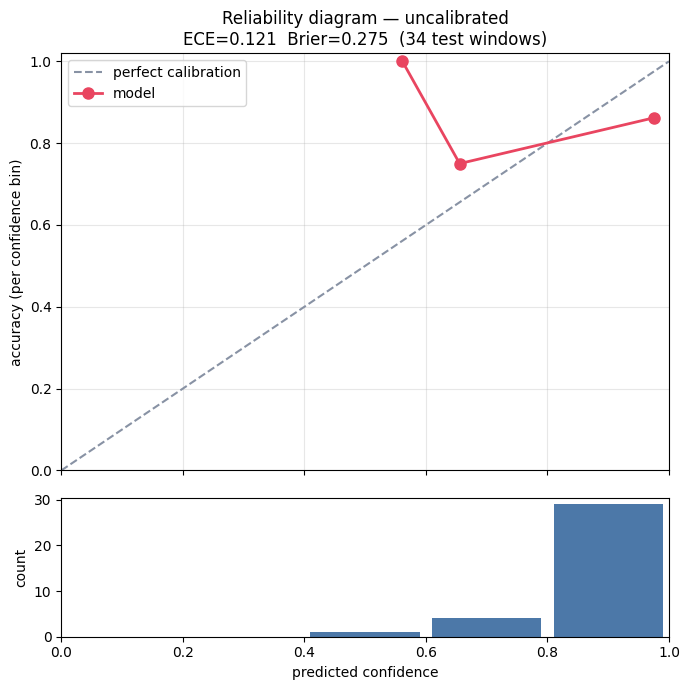

In [3]:
# Reliability diagram (uncalibrated)
centers, acc, conf, count = reliability_curve(conf_raw, correct_raw, N_BINS)
fig, (axr, axc) = plt.subplots(
    2, 1, figsize=(7, 7), sharex=True, gridspec_kw=dict(height_ratios=[3, 1])
)
axr.plot([0, 1], [0, 1], "--", color="#8892a4", label="perfect calibration")
m = count > 0
axr.plot(conf[m], acc[m], "o-", color="#e94560", linewidth=2, markersize=8, label="model")
axr.set_ylabel("accuracy (per confidence bin)")
axr.set_title(f"Reliability diagram — uncalibrated\nECE={ece_raw:.3f}  Brier={brier_raw:.3f}  (34 test windows)")
axr.legend(loc="upper left")
axr.grid(True, alpha=0.3)
axr.set_xlim(0, 1)
axr.set_ylim(0, 1.02)
axc.bar(centers, count, width=1 / N_BINS * 0.9, color="#4c78a8")
axc.set_ylabel("count")
axc.set_xlabel("predicted confidence")
fig.tight_layout()
fig.savefig(FIG / "phase5b_reliability.png", dpi=110, bbox_inches="tight")
plt.show()

Points **below** the diagonal mean the model is **over-confident** there (it claims more certainty than its hit-rate justifies); above means under-confident. The bottom panel is the per-bin sample count — with 34 windows most bins are nearly empty, so don't over-read individual points.

## The fix — isotonic & Platt scaling

Both are post-hoc recalibrations of a frozen model, fit on the held-out **validation** fold and evaluated on **test**:

- **Platt (sigmoid):** fit a logistic curve mapping scores → probabilities. Few parameters → stable on small data, but can only apply a smooth monotonic squash.
- **Isotonic:** fit a free monotonic step function. More flexible → can fix odd shapes, but **data-hungry** and prone to over-fitting on tiny folds (exactly our risk here).

In [4]:
results = {"uncalibrated": (acc_raw, ece_raw, brier_raw)}
proba_by_method = {"uncalibrated": proba_raw}

for method in ("sigmoid", "isotonic"):
    cc = CalibratedClassifierCV(FrozenEstimator(model), method=method).fit(Xval, yval)
    p = cc.predict_proba(Xte)
    c, ok = confidence_and_correct(p, yte)
    results[method] = (ok.mean(), expected_calibration_error(c, ok, N_BINS), multiclass_brier(yte, p))
    proba_by_method[method] = p

summary = pd.DataFrame(results, index=["accuracy", "ECE", "Brier"]).T.round(3)
summary

,accuracy,ECE,Brier
uncalibrated,0.853,0.121,0.275
sigmoid,0.824,0.131,0.268
isotonic,0.853,0.120,0.224


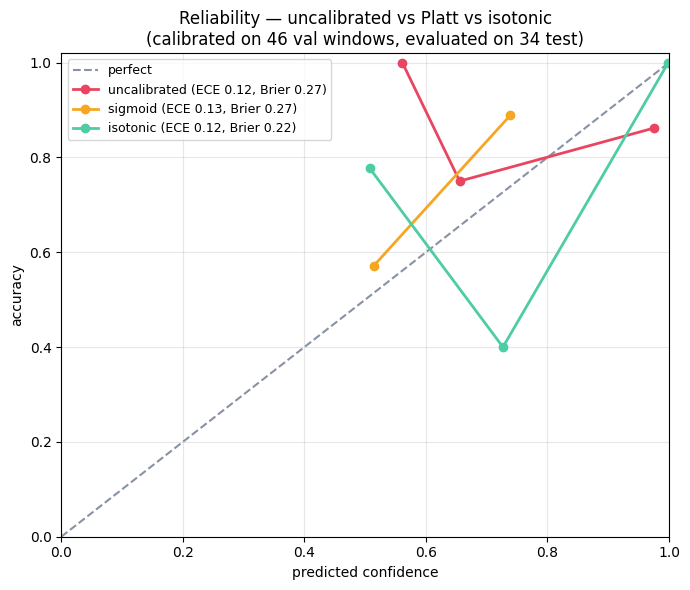

In [5]:
# Reliability curves: uncalibrated vs Platt vs isotonic
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "--", color="#8892a4", label="perfect")
colors = {"uncalibrated": "#e94560", "sigmoid": "#f5a623", "isotonic": "#4ecca3"}
for name, proba in proba_by_method.items():
    c, ok = confidence_and_correct(proba, yte)
    _, a, cf, cnt = reliability_curve(c, ok, N_BINS)
    m = cnt > 0
    label = f"{name} (ECE {results[name][1]:.2f}, Brier {results[name][2]:.2f})"
    ax.plot(cf[m], a[m], "o-", color=colors[name], linewidth=2, label=label)
ax.set_xlabel("predicted confidence")
ax.set_ylabel("accuracy")
ax.set_title("Reliability — uncalibrated vs Platt vs isotonic\n(calibrated on 46 val windows, evaluated on 34 test)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
fig.tight_layout()
fig.savefig(FIG / "phase5b_reliability_compare.png", dpi=110, bbox_inches="tight")
plt.show()

## Interpretation (honest)

- **What to read:** the summary table is the bottom line — does ECE / Brier drop after calibration *on the held-out test fold*? At **N=34 test / 46 calibration**, expect noisy, possibly *worse* results from isotonic (it over-fits the tiny calibration fold), with Platt safer. Whatever the table shows, that is the honest finding — calibration is not guaranteed to help when you barely have data to fit the calibrator.

- **The transferable point:** this is the same **small-data calibration fragility** that undermines the Phase-4 streaming aggregator — its per-detector isotonic calibrators are fit on only 18 sessions, which is *why* the combined risk saturates (see `docs/STREAMING.md` → Phase 4.1). 5b makes that failure mode measurable rather than anecdotal.

- **Production angle:** once there are enough recordings, the workflow is exactly this — fit a calibrator on a held-out fold, verify ECE drops on a separate test fold, *then* set the flag/ban threshold on the now-trustworthy probabilities. The metric code (`pipeline/calibration.py`) and this notebook are the reusable harness.

Figures: `reports/figures/phase5b_*.png`.